Outline:

* Data Loading and Window Creation
* Create splits by sessions, with roughly same class balance
* Custom map-style Dataset
* Visualize some training frames
* Assessing and Addressing Class Imbalance in Training Set
    * Inverse-frequency
    * Class balanced (Cui, et. al., 2019)
* Models
    * Deep CNN
    * Shallow CNN
* Trainer class
* Run exeriment class
* Running Deep Model Experiment
    * With inverse frequency class weighting
        *  Data, stats, best (noise, db shift) pair and best model test accuracy
    * With  Cui et. al., 2019 weighting
        *  Data, stats, best (noise, db shift) pair and best model test accuracy
* Running Shallow Model Experiment
    *  Data, stats, best (noise, db shift) pair and best model test accuracy
 


In [2]:
import numpy as np 
import pandas as pd
import random
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

### Data Loading and Window Creation

In [3]:
import os

# Lets count the amount of sessions and individual files we have and while doing so, check that our paths are correct. 
data_dir = "../RDRD_dataset" 
subject_type = ["Cars", "Drones", "People"]
frames_per_sample = 3
SEED = 42
LR = 1e-3
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
BATCH_SIZE = 32
EPOCHS = 60

# Check data_dir is there, if so, for each subject type (class), check the path data_dir/subject_type
assert os.path.isdir(data_dir), f"data directory is not present at: {data_dir}"

for subject in subject_type:
    # create data_path to directory containing all sessions
    data_path = os.path.join(data_dir, subject)
    assert os.path.isdir(data_path), f"data folder is not present at: {data_path}"
    # Create list of all the session folders to count
    sessions = [session_file for session_file in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, session_file)) ]
    # Count all the csv files in every session and prnt number of sessions and number of total files
    num_files = sum(1 for _, _, files in os.walk(data_path) for f in files if f.lower().endswith(".csv"))   
    print(f"{subject}: has {len(sessions)} session folders and {num_files} csv files total")

Cars: has 27 session folders and 5723 csv files total
Drones: has 21 session folders and 5065 csv files total
People: has 32 session folders and 6700 csv files total


In [4]:
# set random seeds for reproduciblity. 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


### The frames and are labeled numerically 001.csv, 002.csv in recording order. 
* We will create windows where each window contains frames_per_window frames.
     * For example, if frames_per_window = 3: w_1= [f1 f2 f3].
     *  Windows will overlap with a stride of 1, so w_2= [f2 f3 f4].
* Following DopplerNet (Roldan et al. 2020), we use 3 consecutive frames, stacked channels of a torch tensor. Each window sample has shape (3, 11, 61), where each frame is CFAR + trimmed 11x61 range-doppler matrix (power in dB). 

We will split at the *session level*. This is because our windows overlap (as described above), so if two windows that share framed ended up in different splits (for example one in test/one in train), information would leak across the split. The DopplerNet paper evaluates with a random 5-fold split over samples, which can allow this leakage between temorally correlated frames. So our numbers are not directly comparable to the paper's. Their cited test accuracy is 99.4%. 

We organize our data in a dictionary, give each a session_id to track its session, track class ("subject_type").

### Create Windows

In [5]:
def get_label_num(fname: str) -> tuple[int,str]:
    """ grab number corresponding to file name. This works because files are in format e.g. '001.csv', 
        where sequence of positive integers in file title corresponds to order it was recorded (001 was recorded first, then 002, etc).
        Args:
            fname (str): The name of file to parse
        Returns: 
            tuple[int,str]: A tuple containing:
            - int: extracted file number (0 if missing).
            - str: Original file name. 
    """
    # store all sequences of one or more digits as a list, pick the first (should be just one).
    num_label = re.findall(r'\d+',fname)
    return (int(num_label[0]) if num_label else 0, fname) 

# Create a list of dictionaries. For each class name, for each session, list all paths to files. 
# recall subject_type = ["Cars", "Drones", "People"], data_dir = "RDRD_dataset" 

sessions_list = []
for class_name in subject_type: 
    class_dir = os.path.join(data_dir, class_name)
    
    for session_name in sorted(os.listdir(class_dir)): 
        session_dir = os.path.join(class_dir,session_name)
        
        if not os.path.isdir(session_dir):
            continue
        csv_files_list = [f for f in os.listdir(session_dir) if f.lower().endswith('.csv')]
        csv_files_list = sorted(csv_files_list, key = get_label_num)
        file_path_list = [os.path.join(session_dir, file) for file in csv_files_list]
        
        if len(file_path_list) >= frames_per_sample: 
            sessions_list.append({"class": class_name, "session_id": session_name, "paths": file_path_list })
        else: 
            print(f"Skipped {class_name}/{session_name}, only {len(csv_files_list)} frames < frames per sample {frames_per_sample}" )
print(f"Total usable sessions: {len(sessions_list)}")
            
        
# Create a dic of session_id by class so we can begin to stratify our data by class. 
# (list_of_N_paths, label_idx, session_id)
class_to_idx = {cname: i for i, cname in enumerate(subject_type)}
print(class_to_idx)
all_windows = []

# since we are sliding our windows over by 1 each time, if you have len(files) number of files, 
# that gives len(files) - frames_per_sample + 1 number of windows. 
for sess_id, sess in enumerate(sessions_list):
    label = class_to_idx[sess["class"]]
    files = sess["paths"]
    
    for start in range(len(files)- frames_per_sample +1):
        window_paths = files[start:start+frames_per_sample] 
        all_windows.append((window_paths, label, sess_id))
        
print(f"Total windowed samples (before split): {len(all_windows)}")
print(all_windows[0])


Total usable sessions: 80
{'Cars': 0, 'Drones': 1, 'People': 2}
Total windowed samples (before split): 17325
(['../RDRD_dataset/Cars/13-13/001.csv', '../RDRD_dataset/Cars/13-13/002.csv', '../RDRD_dataset/Cars/13-13/003.csv'], 0, 0)


## Create splits by sessions, with roughly same class balance

In [6]:
 # Want to have the same representation of class in each of train/test/val. 
 # So for each class, assign 15% of sessions to val, 15% to test, and 70% to train. So after one class, each set of session ids assigned 
#should look like :
    # val: [0,1,2,3]
    # test: [4:8]= [4,5,6,7]
    # train: [8,9,10,.....]
# however, we want to randomize the sessions that are assigned so it would look more like 
 # val: [45,3,69,4] 
    # test: [9,30,5,10]
    # train: [11,42,23,.....]
# and then these will grow as you assign for the other classes



rng = random.Random(SEED)

sessions_by_class = {c: [] for c in subject_type}
for sess_id, sess in enumerate(sessions_list):
    sessions_by_class[sess["class"]].append(sess_id)

train_sess_ids, val_sess_ids, test_sess_ids = set(), set(), set()
for cname, ids in sessions_by_class.items():
    ids = ids[:]
    rng.shuffle(ids)
    n = len(ids)

    n_val = max(1, int(n*VAL_SPLIT))
    n_test = max(1, int(n*TEST_SPLIT))
 
    val_sess_ids.update(ids[:n_val])
    test_sess_ids.update(ids[n_val:n_val+n_test])
    train_sess_ids.update(ids[n_val+n_test:])
    print(f"{cname}: {n} sessions -> train {n-n_val-n_test}, val {n_val}, test {n_test}")

    #print(f"these are the val ids: {val_sess_ids}")
    #print(f"these are the test ids: {test_sess_ids}")
    #print(f"these are the train ids: {train_sess_ids}")
    #print(f"checking they are disjoint, their intersection is:{val_sess_ids & test_sess_ids & train_sess_ids} ")


train_windows = [w for w in all_windows if w[2] in train_sess_ids ]
test_windows = [w for w in all_windows if w[2] in test_sess_ids ]
val_windows = [w for w in all_windows if w[2] in val_sess_ids ]
print(f"Windowed samples -> train: {len(train_windows)} val: {len(val_windows)}, test: {len(test_windows)}")

Cars: 27 sessions -> train 19, val 4, test 4
Drones: 21 sessions -> train 15, val 3, test 3
People: 32 sessions -> train 24, val 4, test 4
Windowed samples -> train: 13414 val: 1983, test: 1928


In [45]:
print(train_windows[0])

(['../RDRD_dataset/Cars/13-13/001.csv', '../RDRD_dataset/Cars/13-13/002.csv', '../RDRD_dataset/Cars/13-13/003.csv'], 0, 0)


### Custom map-style Dataset

In [42]:
class RDRD_win_data(Dataset):
    """Windows of consecutive radar frames. Each CSV is parsed and normalized once, then cached.
    windows: list of (window_paths, label, sess_id), where window_paths holds
    frames_per_sample CSV paths in order (['RDRD_dataset/Cars/13-13/001.csv', '.../002.csv', '.../003.csv'], 0, 0).
    Each sample is stacked to shape (frames_per_sample, H, W).
         Args:
            Dataset: Dataset to be stacked/shifted/noise added.
        Returns: 
            tensor (torch tensor): Tensor containing processed data.
            label (int): (car = 0, drone = 1, person = 2).
    """

    def __init__(self, windows, norm_stats, noise_std=0.0, shift_db=None):
        self.windows = windows
        self.mean, self.std = norm_stats
        self.noise_std = noise_std
        self.shift_db = shift_db
        unique_paths = {fp for paths,_ ,_ in windows for fp in paths}
        self.cache = {fp: ((self._load_matrix(fp) - self.mean) / self.std).astype(np.float32)
                    for fp in unique_paths}
        
    def __len__(self):
        return len(self.windows)
        
    @staticmethod
    def _load_matrix(fp):
        return np.loadtxt(fp, dtype = np.float32 , delimiter = ",")

    def __getitem__(self, idx):
        paths, label ,_ = self.windows[idx]
        stacked = np.stack([self.cache[fp] for fp in paths], axis = 0)
        tensor = torch.from_numpy(stacked)
        if self.shift_db is not None:
            c = np.random.uniform(-self.shift_db, self.shift_db)
            tensor = tensor + c/self.std
        if self.noise_std > 0:
            tensor = tensor + torch.randn_like(tensor)*self.noise_std
        return tensor, label


In [8]:
# Determine train-set normalization stats
# Compute mean and std over a sample of frames in train split
# grab paths from train_windows, add to sample_paths
# shuffle paths and sample (we'll set to grab the first 2k frames for reproducability speed. Here we don't even had 2k frames)
# load data using np.loadtext and append, stack along channel axis, get global mean, global std

sample_vals = []
sample_paths = set()
# print(train_windows[0])
#(['RDRD_dataset/Cars/13-13/001.csv', 'RDRD_dataset/Cars/13-13/002.csv', 'RDRD_dataset/Cars/13-13/003.csv'], 0, 0)

for paths, _ , _ in train_windows:
    sample_paths.update(paths)
    
sample_paths = list(sample_paths)
rng.shuffle(sample_paths)

for fp in sample_paths[:2000]:
    sample_vals.append(np.loadtxt(fp, dtype = np.float32, delimiter = ","))
    
sample_vals = np.stack(sample_vals, axis = 0)
data_mean, data_std = float(sample_vals.mean()), float(sample_vals.std())
print(f"Train mean: {data_mean} | Train std: {data_std}")

Train mean: -111.8096923828125 | Train std: 9.732627868652344


### Visualize some training frames

 Each tensor mats has shape (B, frames_per_sample, H, W): torch.Size([32, 3, 11, 61])


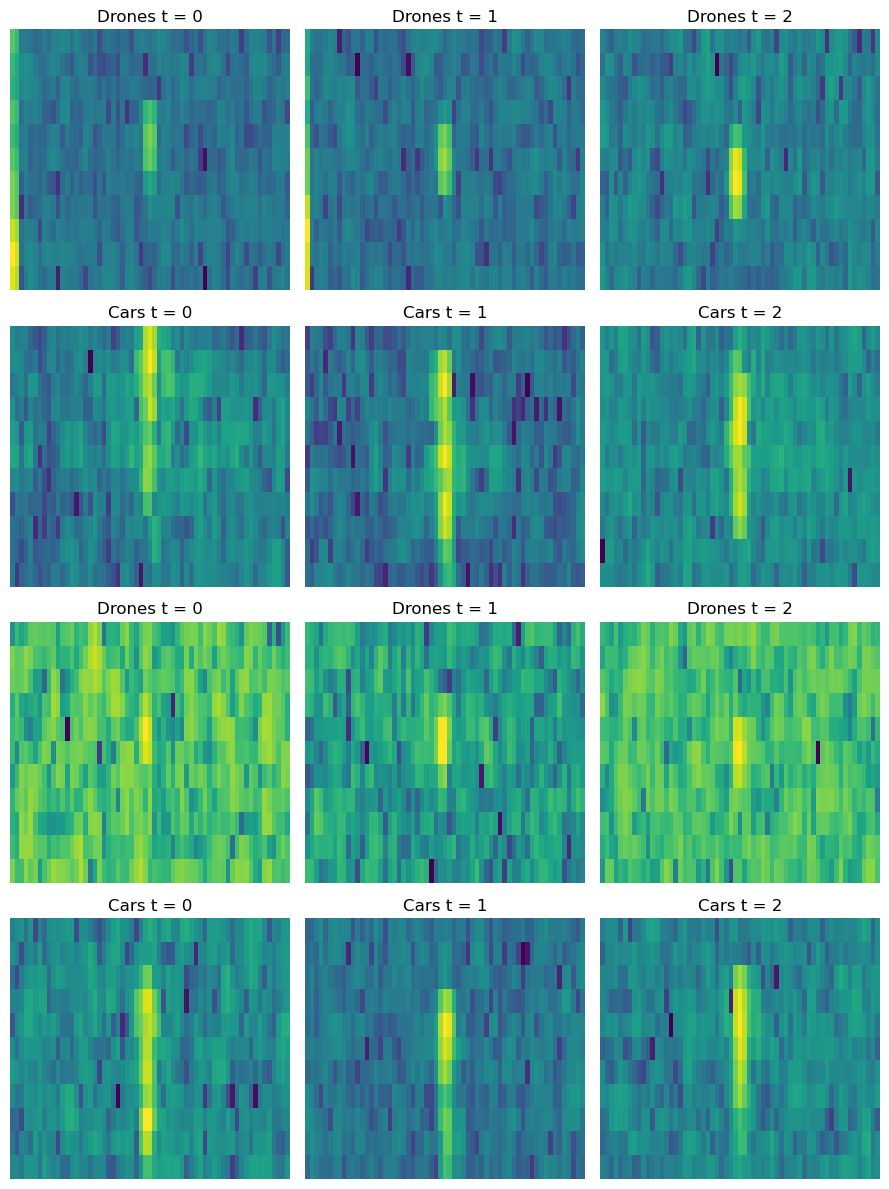

In [43]:
# limit to 4 batches
train_ds = RDRD_win_data(train_windows, (data_mean, data_std))
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True)
                
mats, labels = next(iter(train_loader))
print(f" Each tensor mats has shape (B, frames_per_sample, H, W): {mats.shape}")
n_show = min(4, mats.size(0))

# Build n_show x frames_per_sample axes
# Numpy/Matplotlib needs data on cpu. For each frame, detach, attach to cpu, cast to numpy array, reverse normalization
# for 2D image display can use axes.imshow
# for title, convert numerical 0,1,2 to Cars, People, Drones, recall subject_type = ["Cars", "Drones", "People"], 

fig, axes = plt.subplots(n_show, frames_per_sample, figsize=(3 * frames_per_sample, 3 * n_show))
if n_show == 1:
    axes = axes[None, :]
    
for i in range(n_show):
    for t in range(frames_per_sample):
        mat = mats[i,t].detach().cpu().numpy()* data_std + data_mean
        axes[i,t].imshow(mat, colorizer = "viridis", aspect = "auto")
        axes[i,t].set_title(f"{subject_type[labels[i]]} t = {t}")
        axes[i,t].axis("off")
        
plt.tight_layout()
plt.show()

### Assessing and Addressing Class Imbalance in Training Set 

In [17]:
# Count the windows in our train set, see how they are stratified by class
from collections import Counter

train_labels = [w[1] for w in train_windows]
class_count = Counter(train_labels)
class_count_names = {subject_type[k]:v for k,v in class_count.items()}


print(f"There are a total of {len(train_labels)} windows in our train set, broken down by class as\n {class_count_names}")
print(f"Just double-checking {len(train_labels)} = {sum(class_count.values())}" )


There are a total of 13414 windows in our train set, broken down by class as
 {'Cars': 4263, 'Drones': 3954, 'People': 5197}
Just double-checking 13414 = 13414


## Baseline: Inverse-frequency class weighting
The DopplerNet paper does not apply any class weighting. It describes the RDRD dataset as well-balanced: 32.7% drones, 29.0% people, and 38.3% people. Our training spit is similarly mild, but we still try a more nuanced approached to weighting. 

In [19]:
if_class_weights = torch.tensor([len(train_labels)/class_count.get(i,1) for i in range(len(subject_type))],dtype = torch.float32, device = device)
# normalize (divide by sum of weights), make them sum to number of classes (multiply by # of classes)
if_class_weights = if_class_weights/if_class_weights.sum()*len(subject_type)
print(if_class_weights)

tensor([1.0350, 1.1159, 0.8490], device='mps:0')


## Alternative: Class-balanced loss. [(Cui, et al., 2019)](https://www.computer.org/csdl/proceedings-article/cvpr/2019/329300j260/1gyrmDpnl72) 

We introduce the hyperparameter $\beta = (N-1)/N$ where N is either total training samples or number of samples in the largest class. Instead of weighting by $1/ n_c$, we weight by a fixed $1/E(n_c)$ where $E(n_c) = (1-\beta)/(1-\beta^{n_c})$

In [20]:
total_samples = len(train_labels)
beta = (total_samples -1)/ total_samples
count_tensor = torch.tensor([class_count.get(i,1) for i in range(len(subject_type))], dtype = torch.float32, device = device)
den_tensor = 1.0 - torch.pow(beta, count_tensor)
class_weights = (1.0 - beta)/den_tensor
class_weights = class_weights/class_weights.sum()*len(subject_type)
print("Counts:", count_tensor.tolist())
print("Weights:", class_weights.tolist())
print(class_weights)

Counts: [4263.0, 3954.0, 5197.0]
Weights: [1.0294981002807617, 1.0978827476501465, 0.8726191520690918]
tensor([1.0295, 1.0979, 0.8726], device='mps:0')


## Models

### Deep Model

In [21]:
class RDRD_CNN(nn.Module):
    def __init__(self, num_classes, in_channels, in_shape):
        super().__init__()
        h,w = in_shape 
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, out_channels = 32, kernel_size = 3, padding = 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size = (1,2)),
            nn.Conv2d(64, 128, kernel_size = 3, padding = 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size = (1,2)),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, h,w)
            flat_dim = self.features(dummy).numel()
            
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),        
        )
        
    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)

### Shallow Model

In [22]:
class Shallow_RDRD_CNN(nn.Module):
    def __init__(self, num_classes, in_channels, in_shape ,pool_hw):
        super().__init__()
        h,w = in_shape 
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, out_channels = 32, kernel_size = 3, padding = 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size = (1,2)),
            nn.AdaptiveAvgPool2d(pool_hw),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, h,w)
            flat_dim = self.features(dummy).numel()
            
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(flat_dim, num_classes),        
        )
        
    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)

### Trainer class

In [23]:
class Trainer:
    """Runs train/val epochs with early stopping and restores the best-validation weights."""
    def __init__(self,model, train_loader, val_loader, optimizer, criterion, lr_scheduler, device, epochs = 50):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.epochs = epochs
        
    def epoch_run(self, train_mode = True):
        """Run one epoch over the train or val loader and return (avg loss, accuracy)."""
        total_loss, correct, total = 0.0, 0, 0
        
        if train_mode:
            self.model.train() 
        else:
            self.model.eval()
        with torch.set_grad_enabled(train_mode):
            loader = self.train_loader if train_mode else self.val_loader
            for (mats, labels) in loader:
                mats, labels = mats.to(self.device), labels.to(self.device)
                
                if train_mode:
                    self.optimizer.zero_grad()
                outputs = self.model(mats)
                loss = self.criterion(outputs, labels)
                
                if train_mode:
                    loss.backward()
                    self.optimizer.step()
                total_loss += loss.item()*mats.size(0)
                preds = outputs.argmax(dim = 1)
                correct += (preds == labels).sum().item()
                total+= mats.size(0)
                
        return total_loss/total, correct/total
        
    def fit(self, EPOCHS = None, patience = 10):
        """Train for up to EPOCHS, stopping early after 'patience' epochs elapse without val accuracy improvement.
        Returns the per epoch history dict."""
        EPOCHS = self.epochs if EPOCHS is None else EPOCHS
        history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
        best_val_acc = 0.0
        best_state = None
        patience_counter = 0
        
        for epoch in range(1, EPOCHS+1):
            tr_loss, tr_acc = self.epoch_run(train_mode = True)
            val_loss, val_acc = self.epoch_run(train_mode = False)
            self.lr_scheduler.step(val_loss)
            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            
            print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss {tr_loss:.4f}, Train Acc {tr_acc:.4f}  | Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.cpu().clone() for k,v in self.model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter+= 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs).")
                    break
                    
        if best_state is not None:
            self.model.load_state_dict(best_state)
            
        print(f"\nBest validation accuracy: {best_val_acc:.3f}")
        
        return history
        
    def evaluate(self, loader):
        """Return loss, accuracy, and all predictions and labels for the loader set"""
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [],[]
        
        with torch.no_grad():
            for mats, labels in loader:
                mats, labels = mats.to(self.device), labels.to(self.device)
                outputs = self.model(mats)
                loss = self.criterion(outputs, labels)
                preds = outputs.argmax(axis = 1)
                total_loss += loss.item()*mats.size(0)
                correct+= (preds == labels).sum().item()
                total+= mats.size(0)
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        return ((total_loss/total), correct/total, torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy())

### Run experiment class

In [41]:
import copy

class radar_CNN_exp:
    """Runs experiment with sweeps of gaussian noise and dB shift"""
    def __init__(self, model, test_loader, val_loader, noise_list, shift_list, device, batch_size = 64, epochs = 50, lr = 1e-3, baseline_weighting = False):
        self.init_model = copy.deepcopy(model).cpu()
        self.test_loader = test_loader
        self.val_loader = val_loader
        self.noise_list = noise_list
        self.shift_list = shift_list
        self.device = device
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.baseline_weighting = baseline_weighting
        self.model_dic = {}
        print(f"model: {self.init_model.__class__.__name__}")
        
    def run(self):
        for noise_std in self.noise_list:
            for shift_db in self.shift_list:
                print(f"\n ~~~ noise_std: {noise_std} | shift_db = {shift_db}~~~")
                torch.manual_seed(0)
                np.random.seed(0)

                model = copy.deepcopy(self.init_model).to(self.device)
                train_ds = RDRD_win_data(train_windows, (data_mean, data_std), noise_std = noise_std, shift_db = shift_db)
                train_loader = DataLoader(train_ds, batch_size = self.batch_size, shuffle = True)
                
                params = sum(p.numel() for p in model.parameters() if p.requires_grad)
                optimizer = optim.Adam(model.parameters(), lr=self.lr, weight_decay=1e-4)
                scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)
                if self.baseline_weighting:
                    weighting = if_class_weights
                else: 
                    weighting = class_weights
                criterion = nn.CrossEntropyLoss(weight = weighting)

                print(f"Trainable parameters: {params:,}")
                
                trainer = Trainer(model, train_loader, self.val_loader, optimizer, criterion, scheduler, self.device)
                history= trainer.fit(EPOCHS = self.epochs, patience=10)
                val_loss, val_acc, _, _ = trainer.evaluate(self.val_loader)
                self.model_dic[(noise_std,shift_db)]= {"history":history, "val_loss": val_loss, "val_acc":val_acc, "epochs_run":len(history["val_acc"]),"state_dict":{k: v.cpu().clone() for k,v in model.state_dict().items()}}
                del model, optimizer, scheduler, trainer

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        
        return self.model_dic

## Deep Model

## Inverse-Frequency Class Weighting

In [31]:
BATCH_SIZE = 32
EPOCHS = 60
LR = 1e-3
test_ds = RDRD_win_data(test_windows, (data_mean, data_std))
val_ds = RDRD_win_data(val_windows, (data_mean, data_std))
               
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle = False)
model = RDRD_CNN(num_classes=len(subject_type), in_channels=frames_per_sample, in_shape=(11, 61)).to(device)

if_experiment = radar_CNN_exp(model = model, test_loader = test_loader, val_loader = val_loader, noise_list = [0, 0.1, 0.2], shift_list = [0, 1, 2, 3], device = device, batch_size = BATCH_SIZE, epochs = EPOCHS, lr = LR, baseline_weighting = True)
if_model_data_dic = if_experiment.run()

model: RDRD_CNN

 ~~~ noise_std: 0 | shift_db = 0~~~
Trainable parameters: 2,797,571
Epoch  1/60 | Train Loss 0.2844, Train Acc 0.9136  | Val Loss 0.1144, Val Acc 0.9627
Epoch  2/60 | Train Loss 0.1183, Train Acc 0.9604  | Val Loss 0.1024, Val Acc 0.9743
Epoch  3/60 | Train Loss 0.0963, Train Acc 0.9687  | Val Loss 0.0856, Val Acc 0.9753
Epoch  4/60 | Train Loss 0.0835, Train Acc 0.9732  | Val Loss 0.1574, Val Acc 0.9657
Epoch  5/60 | Train Loss 0.0759, Train Acc 0.9764  | Val Loss 0.1252, Val Acc 0.9702
Epoch  6/60 | Train Loss 0.0640, Train Acc 0.9785  | Val Loss 0.0646, Val Acc 0.9813
Epoch  7/60 | Train Loss 0.0614, Train Acc 0.9801  | Val Loss 0.0896, Val Acc 0.9798
Epoch  8/60 | Train Loss 0.0511, Train Acc 0.9835  | Val Loss 0.0681, Val Acc 0.9803
Epoch  9/60 | Train Loss 0.0527, Train Acc 0.9833  | Val Loss 0.0710, Val Acc 0.9829
Epoch 10/60 | Train Loss 0.0366, Train Acc 0.9885  | Val Loss 0.0767, Val Acc 0.9763
Epoch 11/60 | Train Loss 0.0474, Train Acc 0.9847  | Val Loss 0.0

In [37]:
if_deep_summary = pd.DataFrame([{"noise_std":k[0], "shift_db":k[1],"val_loss":v["val_loss"],"val_acc":v["val_acc"],"epochs":v["epochs_run"]} for k,v in if_model_data_dic.items()]).sort_values("val_acc", ascending = False)
print(if_deep_summary)
print("\n",if_deep_summary.pivot(index= "noise_std" , columns = "shift_db", values = "val_acc").round(4))
best_key = max(if_model_data_dic, key = lambda k: if_model_data_dic[k]["val_acc"])
print("Best config:", best_key)

best_deep_model = RDRD_CNN(len(subject_type), frames_per_sample, (11,61)).to(device)
best_deep_model.load_state_dict(if_model_data_dic[best_key]["state_dict"])
criterion = nn.CrossEntropyLoss(weight = if_class_weights)

evaluator = Trainer(best_deep_model, None, val_loader, None, criterion, None, device)
test_loss, test_acc, test_preds, test_labels = evaluator.evaluate(test_loader)
print(f"Test loss {test_loss:.4f} | Test acc {test_acc:.4f}")



print(classification_report(test_labels, test_preds, target_names=subject_type))
print(confusion_matrix(test_labels, test_preds))

    noise_std  shift_db  val_loss   val_acc  epochs
11        0.2         3  0.055466  0.984367      18
9         0.2         1  0.054498  0.983863      15
10        0.2         2  0.054927  0.983863      15
0         0.0         0  0.071472  0.983359      23
4         0.1         0  0.070298  0.983359      30
1         0.0         1  0.084303  0.982854      23
2         0.0         2  0.087550  0.982854      21
8         0.2         0  0.082002  0.982854      24
5         0.1         1  0.077496  0.982350      20
6         0.1         2  0.077706  0.981846      26
3         0.0         3  0.079377  0.980333      18
7         0.1         3  0.080116  0.979324      16

 shift_db        0       1       2       3
noise_std                                
0.0        0.9834  0.9829  0.9829  0.9803
0.1        0.9834  0.9823  0.9818  0.9793
0.2        0.9829  0.9839  0.9839  0.9844
Best config: (0.2, 3)
Test loss 0.3646 | Test acc 0.9694
              precision    recall  f1-score   support



## Deep Model 
## (Cui, et. al., 2019) Class balancing. 

In [77]:

model = RDRD_CNN(num_classes=len(subject_type), in_channels=frames_per_sample, in_shape=(11, 61)).to(device)

experiment = radar_CNN_exp(model = model, test_loader = test_loader, val_loader = val_loader, noise_list = [0, 0.1, 0.2], shift_list = [0, 1, 2, 3], device = device, batch_size = BATCH_SIZE, epochs = EPOCHS, lr = LR)
model_data_dic = experiment.run()

model: RDRD_CNN

 ~~~ noise_std: 0 | shift_db = 0~~~
Trainable parameters: 2,797,571
Epoch  1/60 | Train Loss 0.2582, Train Acc 0.9202  | Val Loss 0.0743, Val Acc 0.9738
Epoch  2/60 | Train Loss 0.1197, Train Acc 0.9606  | Val Loss 0.0596, Val Acc 0.9829
Epoch  3/60 | Train Loss 0.0944, Train Acc 0.9688  | Val Loss 0.0913, Val Acc 0.9687
Epoch  4/60 | Train Loss 0.0792, Train Acc 0.9749  | Val Loss 0.0720, Val Acc 0.9783
Epoch  5/60 | Train Loss 0.0725, Train Acc 0.9766  | Val Loss 0.1011, Val Acc 0.9753
Epoch  6/60 | Train Loss 0.0582, Train Acc 0.9798  | Val Loss 0.1060, Val Acc 0.9728
Epoch  7/60 | Train Loss 0.0567, Train Acc 0.9805  | Val Loss 0.0536, Val Acc 0.9798
Epoch  8/60 | Train Loss 0.0458, Train Acc 0.9852  | Val Loss 0.0678, Val Acc 0.9793
Epoch  9/60 | Train Loss 0.0500, Train Acc 0.9836  | Val Loss 0.0858, Val Acc 0.9773
Epoch 10/60 | Train Loss 0.0401, Train Acc 0.9864  | Val Loss 0.0606, Val Acc 0.9803
Epoch 11/60 | Train Loss 0.0392, Train Acc 0.9869  | Val Loss 0.1

In [80]:
deep_summary = pd.DataFrame([{"noise_std":k[0], "shift_db":k[1],"val_loss":v["val_loss"],"val_acc":v["val_acc"],"epochs":v["epochs_run"]} for k,v in model_data_dic.items()]).sort_values("val_acc", ascending = False)
print(deep_summary)
print("\n",deep_summary.pivot(index= "noise_std" , columns = "shift_db", values = "val_acc").round(4))
best_key = max(model_data_dic, key = lambda k: model_data_dic[k]["val_acc"])
print("Best config:", best_key)

best_deep_model = RDRD_CNN(len(subject_type), frames_per_sample, (11,61)).to(device)
best_deep_model.load_state_dict(model_data_dic[best_key]["state_dict"])
criterion = nn.CrossEntropyLoss(weight = class_weights)

evaluator = Trainer(best_deep_model, None, val_loader, None, criterion, None, device)
test_loss, test_acc, test_preds, test_labels = evaluator.evaluate(test_loader)
print(f"Test loss {test_loss:.4f} | Test acc {test_acc:.4f}")



print(classification_report(test_labels, test_preds, target_names=subject_type))
print(confusion_matrix(test_labels, test_preds))

    noise_std  shift_db  val_loss   val_acc  epochs
5         0.1         1  0.071063  0.984367      20
9         0.2         1  0.087223  0.984367      18
0         0.0         0  0.059602  0.982854      12
6         0.1         2  0.085808  0.982854      20
7         0.1         3  0.062789  0.982854      15
10        0.2         2  0.073438  0.982350      25
3         0.0         3  0.076437  0.981846      18
11        0.2         3  0.055730  0.981846      17
8         0.2         0  0.078996  0.981341      19
1         0.0         1  0.066924  0.980837      13
2         0.0         2  0.112688  0.980837      21
4         0.1         0  0.065314  0.980837      15

 shift_db        0       1       2       3
noise_std                                
0.0        0.9829  0.9808  0.9808  0.9818
0.1        0.9808  0.9844  0.9829  0.9829
0.2        0.9813  0.9844  0.9823  0.9818
Best config: (0.1, 1)
Test loss 0.3366 | Test acc 0.9741
              precision    recall  f1-score   support



####  No meaningful difference between inverse-frequency and (Cui, et. al., 2019) Class balancing so for our shallow model we will just use the Cui et. al. 2019. 

# Shallow Model

## (Cui, et. al., 2019) Class balancing.

In [81]:
BATCH_SIZE = 32
EPOCHS = 60
LR = 1e-3
test_ds = RDRD_win_data(test_windows, (data_mean, data_std))
val_ds = RDRD_win_data(val_windows, (data_mean, data_std))
               
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle = False)
model = Shallow_RDRD_CNN(num_classes=len(subject_type), in_channels=frames_per_sample, in_shape=(11, 61), pool_hw=(11, 10),).to(device)

experiment2 = radar_CNN_exp(model = model, test_loader = test_loader, val_loader = val_loader, noise_list = [0, 0.1, 0.2], shift_list = [0, 1, 2, 3], device = device, batch_size = BATCH_SIZE, epochs = EPOCHS, lr = LR)
SM_dic = experiment2.run()


model: Shallow_RDRD_CNN

 ~~~ noise_std: 0 | shift_db = 0~~~
Trainable parameters: 40,707
Epoch  1/60 | Train Loss 0.2269, Train Acc 0.9193  | Val Loss 0.0892, Val Acc 0.9682
Epoch  2/60 | Train Loss 0.1054, Train Acc 0.9633  | Val Loss 0.1184, Val Acc 0.9566
Epoch  3/60 | Train Loss 0.0941, Train Acc 0.9674  | Val Loss 0.0726, Val Acc 0.9713
Epoch  4/60 | Train Loss 0.0744, Train Acc 0.9738  | Val Loss 0.0659, Val Acc 0.9768
Epoch  5/60 | Train Loss 0.0692, Train Acc 0.9752  | Val Loss 0.0681, Val Acc 0.9748
Epoch  6/60 | Train Loss 0.0686, Train Acc 0.9773  | Val Loss 0.1153, Val Acc 0.9682
Epoch  7/60 | Train Loss 0.0508, Train Acc 0.9807  | Val Loss 0.0775, Val Acc 0.9723
Epoch  8/60 | Train Loss 0.0468, Train Acc 0.9835  | Val Loss 0.0684, Val Acc 0.9758
Epoch  9/60 | Train Loss 0.0373, Train Acc 0.9881  | Val Loss 0.0739, Val Acc 0.9768
Epoch 10/60 | Train Loss 0.0270, Train Acc 0.9912  | Val Loss 0.0726, Val Acc 0.9753
Epoch 11/60 | Train Loss 0.0195, Train Acc 0.9937  | Val Los

In [82]:
summary = pd.DataFrame([{"noise_std":k[0], "shift_db":k[1],"val_loss":v["val_loss"],"val_acc":v["val_acc"],"epochs":v["epochs_run"]} for k,v in SM_dic.items()]).sort_values("val_acc", ascending = False)
print(summary)

    noise_std  shift_db  val_loss   val_acc  epochs
11        0.2         3  0.087055  0.980837      15
8         0.2         0  0.067421  0.979829      27
10        0.2         2  0.064305  0.979829      18
5         0.1         1  0.066685  0.978820      18
7         0.1         3  0.062589  0.978820      18
1         0.0         1  0.062006  0.978316      19
9         0.2         1  0.067621  0.978316      26
3         0.0         3  0.067351  0.977307      19
6         0.1         2  0.064867  0.977307      19
0         0.0         0  0.065905  0.976803      14
2         0.0         2  0.086471  0.976299      19
4         0.1         0  0.094611  0.976299      25


In [83]:
print("\n",summary.pivot(index= "noise_std" , columns = "shift_db", values = "val_acc").round(4))


 shift_db        0       1       2       3
noise_std                                
0.0        0.9768  0.9783  0.9763  0.9773
0.1        0.9763  0.9788  0.9773  0.9788
0.2        0.9798  0.9783  0.9798  0.9808


In [84]:
best_key = max(SM_dic, key = lambda k: SM_dic[k]["val_acc"])
print("Best config:", best_key)

best_model = Shallow_RDRD_CNN(len(subject_type), frames_per_sample, (11,61), pool_hw = (11,10)).to(device)
best_model.load_state_dict(SM_dic[best_key]["state_dict"])
evaluator = Trainer(best_model, None, val_loader, None, criterion, None, device)
test_loss, test_acc, test_preds, test_labels = evaluator.evaluate(test_loader)
print(f"Test loss {test_loss:.4f} | Test acc {test_acc:.4f}")

print(classification_report(test_labels, test_preds, target_names=subject_type))
print(confusion_matrix(test_labels, test_preds))

Best config: (0.2, 3)
Test loss 0.4047 | Test acc 0.9710
              precision    recall  f1-score   support

        Cars       0.97      0.95      0.96       719
      Drones       0.95      0.98      0.96       540
      People       0.99      0.98      0.98       669

    accuracy                           0.97      1928
   macro avg       0.97      0.97      0.97      1928
weighted avg       0.97      0.97      0.97      1928

[[686  26   7]
 [  9 529   2]
 [ 10   2 657]]
